In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(
    "../data/load_forecasting_features.csv",
    parse_dates=["datetime"]
)

df.head()

,datetime,load,solar,wind_onshore,wind_offshore,temperature,wind_speed,cloud_cover,solar_radiation,hour,...,month,weekday,weekend,load_lag_1,load_lag_24,load_lag_168,rolling_mean_24,rolling_std_24,hour_sin,hour_cos
0,2015-01-08 00:00:00,48041.0,0.0,15273.0,534.0,1.3,15.3,100,0.0,0,...,1,3,0,50460.0,45125.0,41151.0,60234.500000,8884.334704,0.000000,1.000000
1,2015-01-08 01:00:00,47074.0,0.0,15915.0,533.0,1.0,15.6,100,0.0,1,...,1,3,0,48041.0,44217.0,40135.0,60353.541667,8677.107873,0.258819,0.965926
2,2015-01-08 02:00:00,47228.0,0.0,16164.0,531.0,0.8,15.8,96,0.0,2,...,1,3,0,47074.0,44368.0,39106.0,60472.708333,8465.074306,0.500000,0.866025
3,2015-01-08 03:00:00,48253.0,0.0,16258.0,529.0,1.0,16.1,100,0.0,3,...,1,3,0,47228.0,45298.0,38765.0,60595.833333,8253.609944,0.707107,0.707107
4,2015-01-08 04:00:00,51155.0,0.0,16218.0,532.0,1.2,16.7,100,0.0,4,...,1,3,0,48253.0,48598.0,38941.0,60702.375000,8107.207410,0.866025,0.500000


In [6]:
train = df[
    df["datetime"] < "2020-01-01"
]


test = df[
    df["datetime"] >= "2020-01-01"
]

In [7]:
print(train.shape)
print(test.shape)

(43656, 21)
(6576, 21)


In [8]:
features = [
    "solar",
    "wind_onshore",
    "wind_offshore",
    "temperature",
    "wind_speed",
    "cloud_cover",
    "solar_radiation",
    "hour",
    "month",
    "weekday",
    "weekend",
    "load_lag_1",
    "load_lag_24",
    "load_lag_168",
    "rolling_mean_24",
    "rolling_std_24",
    "hour_sin",
    "hour_cos"
]

In [9]:
X_train = train[features]
y_train = train["load"]


X_test = test[features]
y_test = test["load"]

In [10]:
X_train.shape, X_test.shape

((43656, 18), (6576, 18))

In [11]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

print("Training completed")

Training completed


In [12]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np


y_pred_lr = lr.predict(
    X_test
)


mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

mape_lr = mean_absolute_percentage_error(
    y_test,
    y_pred_lr
)


print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("MAPE:", mape_lr)

MAE: 1109.3111637248815
RMSE: 1422.2855183096317
MAPE: 0.021405524722336432


In [13]:
results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae_lr],
    "RMSE": [rmse_lr],
    "MAPE": [mape_lr * 100]
})

results

,Model,MAE,RMSE,MAPE
0,Linear Regression,1109.311164,1422.285518,2.140552


In [14]:
#MODEL RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor


rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


rf.fit(
    X_train,
    y_train
)

print("Random Forest training completed")

Random Forest training completed


In [15]:
y_pred_rf = rf.predict(
    X_test
)

In [16]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

mape_rf = mean_absolute_percentage_error(
    y_test,
    y_pred_rf
)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("MAPE:", mape_rf*100)

MAE: 537.2311374695864
RMSE: 739.0135806852804
MAPE: 1.0402035207096236


In [17]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})


feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)


feature_importance

,Feature,Importance
11,load_lag_1,0.915969
13,load_lag_168,0.034709
16,hour_sin,0.018556
7,hour,0.013964
12,load_lag_24,0.004783
17,hour_cos,0.003289
14,rolling_mean_24,0.002886
0,solar,0.001864
6,solar_radiation,0.000805
3,temperature,0.000614


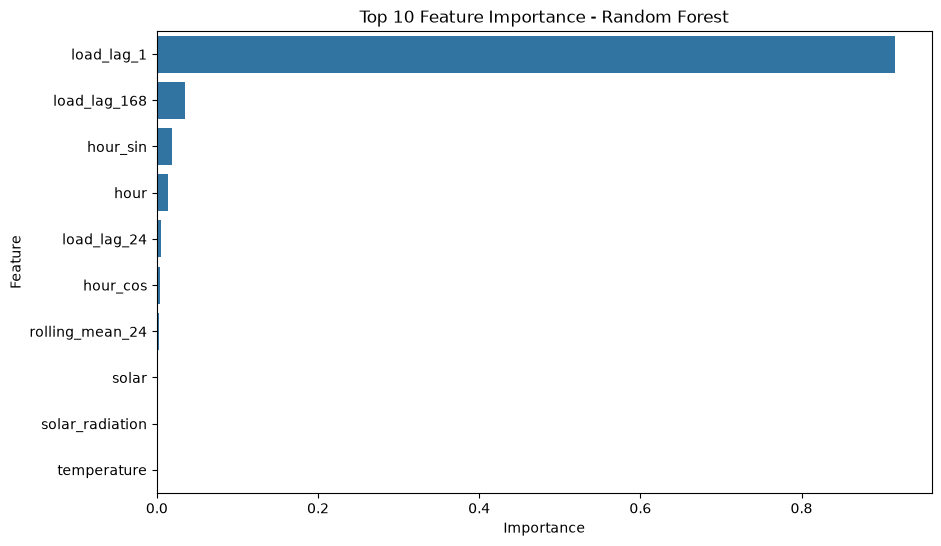

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Feature Importance - Random Forest"
)

plt.show()

In [19]:
comparison = pd.DataFrame({
    "datetime": test["datetime"],
    "actual": y_test,
    "prediction": y_pred_rf
})


comparison.head()

,datetime,actual,prediction
43656,2020-01-01 00:00:00,41187.0,41477.830
43657,2020-01-01 01:00:00,40398.0,41303.385
43658,2020-01-01 02:00:00,38919.0,41452.545
43659,2020-01-01 03:00:00,38879.0,39712.765
43660,2020-01-01 04:00:00,39162.0,39580.660


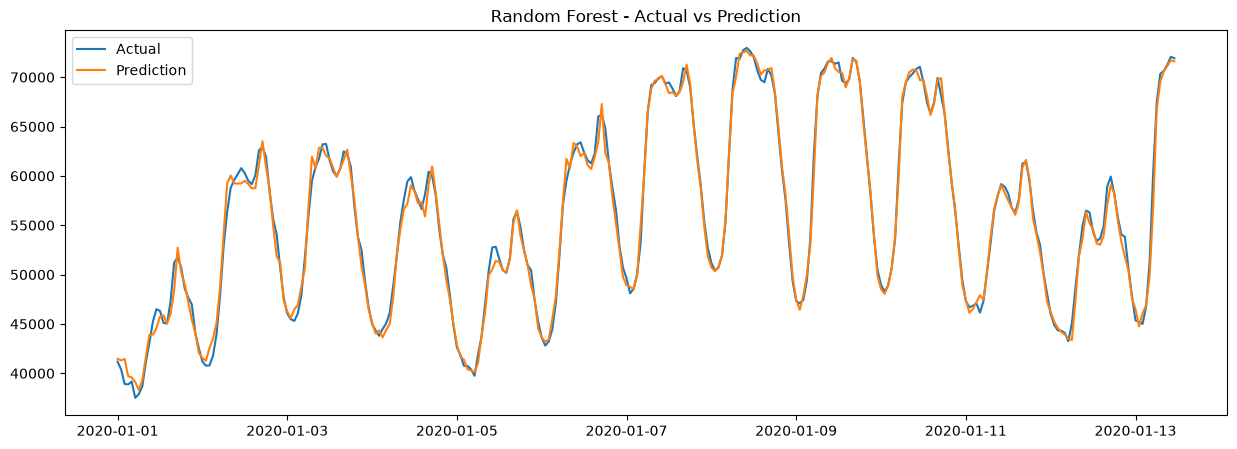

In [20]:
plt.figure(figsize=(15,5))

plt.plot(
    comparison["datetime"][:300],
    comparison["actual"][:300],
    label="Actual"
)

plt.plot(
    comparison["datetime"][:300],
    comparison["prediction"][:300],
    label="Prediction"
)

plt.legend()

plt.title(
    "Random Forest - Actual vs Prediction"
)

plt.show()

In [21]:
from xgboost import XGBRegressor

In [22]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

In [23]:
xgb.fit(
    X_train,
    y_train
)

print("XGBoost training completed")

XGBoost training completed


In [24]:
y_pred_xgb = xgb.predict(
    X_test
)

In [25]:
mae_xgb = mean_absolute_error(
    y_test,
    y_pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb
    )
)

mape_xgb = mean_absolute_percentage_error(
    y_test,
    y_pred_xgb
)


print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("MAPE:", mape_xgb*100)

MAE: 490.6448080615116
RMSE: 650.8989835519244
MAPE: 0.9564738188344034


In [26]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})


xgb_importance = xgb_importance.sort_values(
    "Importance",
    ascending=False
)


xgb_importance

,Feature,Importance
11,load_lag_1,0.665089
13,load_lag_168,0.178278
16,hour_sin,0.042779
10,weekend,0.031206
17,hour_cos,0.018395
9,weekday,0.016092
12,load_lag_24,0.015155
7,hour,0.012203
14,rolling_mean_24,0.009757
0,solar,0.003388


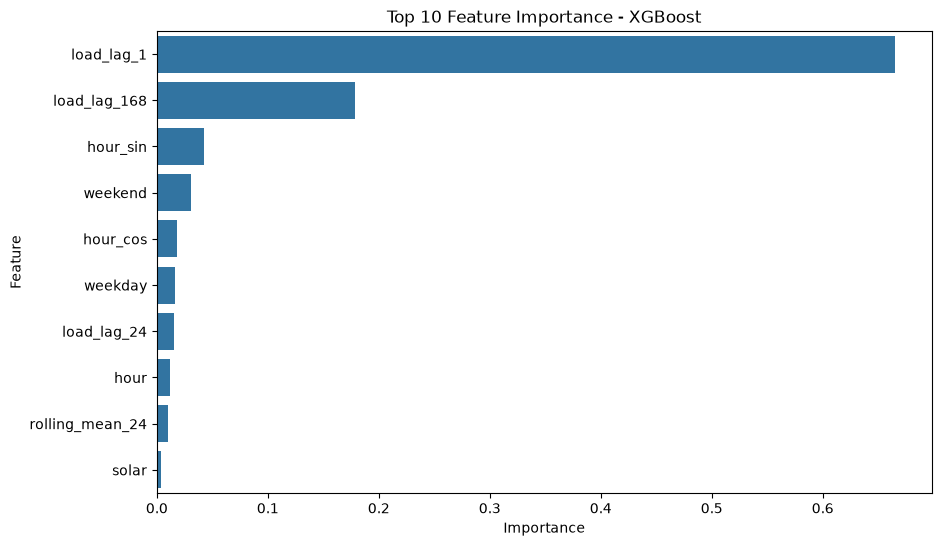

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=xgb_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Feature Importance - XGBoost"
)

plt.show()

In [28]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],
    "MAPE (%)": [
        mape_lr * 100,
        mape_rf * 100,
        mape_xgb * 100
    ]
})


model_comparison

,Model,MAE,RMSE,MAPE (%)
0,Linear Regression,1109.311164,1422.285518,2.140552
1,Random Forest,537.231137,739.013581,1.040204
2,XGBoost,490.644808,650.898984,0.956474


In [29]:
model_comparison_sorted = (
    model_comparison
    .sort_values(
        by="MAE"
    )
    .reset_index(drop=True)
)


model_comparison_sorted

,Model,MAE,RMSE,MAPE (%)
0,XGBoost,490.644808,650.898984,0.956474
1,Random Forest,537.231137,739.013581,1.040204
2,Linear Regression,1109.311164,1422.285518,2.140552


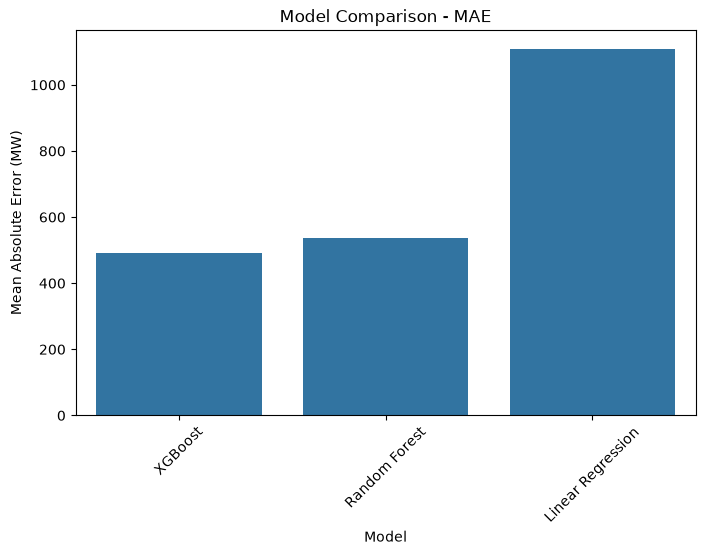

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=model_comparison_sorted,
    x="Model",
    y="MAE"
)

plt.title(
    "Model Comparison - MAE"
)

plt.ylabel(
    "Mean Absolute Error (MW)"
)

plt.xticks(
    rotation=45
)

plt.show()

In [31]:
model_comparison_sorted.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

In [32]:
final_results = {
    "Linear Regression": {
        "MAE": mae_lr,
        "RMSE": rmse_lr,
        "MAPE": mape_lr*100
    },
    "Random Forest": {
        "MAE": mae_rf,
        "RMSE": rmse_rf,
        "MAPE": mape_rf*100
    },
    "XGBoost": {
        "MAE": mae_xgb,
        "RMSE": rmse_xgb,
        "MAPE": mape_xgb*100
    }
}


final_results

{'Linear Regression': {'MAE': 1109.3111637248815,
  'RMSE': np.float64(1422.2855183096317),
  'MAPE': 2.1405524722336433},
 'Random Forest': {'MAE': 537.2311374695864,
  'RMSE': np.float64(739.0135806852804),
  'MAPE': 1.0402035207096236},
 'XGBoost': {'MAE': 490.6448080615116,
  'RMSE': np.float64(650.8989835519244),
  'MAPE': 0.9564738188344034}}

In [33]:
error_analysis = pd.DataFrame({
    "datetime": test["datetime"],
    "actual": y_test,
    "prediction": y_pred_xgb
})


error_analysis.head()

,datetime,actual,prediction
43656,2020-01-01 00:00:00,41187.0,41025.988281
43657,2020-01-01 01:00:00,40398.0,41026.832031
43658,2020-01-01 02:00:00,38919.0,40963.191406
43659,2020-01-01 03:00:00,38879.0,39848.035156
43660,2020-01-01 04:00:00,39162.0,40178.730469


In [34]:
error_analysis["error"] = (
    error_analysis["actual"]
    -
    error_analysis["prediction"]
)


error_analysis["abs_error"] = (
    error_analysis["error"]
    .abs()
)


error_analysis.head()

,datetime,actual,prediction,error,abs_error
43656,2020-01-01 00:00:00,41187.0,41025.988281,161.011719,161.011719
43657,2020-01-01 01:00:00,40398.0,41026.832031,-628.832031,628.832031
43658,2020-01-01 02:00:00,38919.0,40963.191406,-2044.191406,2044.191406
43659,2020-01-01 03:00:00,38879.0,39848.035156,-969.035156,969.035156
43660,2020-01-01 04:00:00,39162.0,40178.730469,-1016.730469,1016.730469


In [35]:
error_analysis["abs_error"].describe()

count    6576.000000
mean      490.644808
std       427.744062
min         0.039062
25%       175.317383
50%       382.494141
75%       683.679688
max      3653.703125
Name: abs_error, dtype: float64

In [36]:
error_analysis["hour"] = (
    error_analysis["datetime"]
    .dt.hour
)


hour_error = (
    error_analysis
    .groupby("hour")["abs_error"]
    .mean()
)


hour_error

hour
0     330.578938
1     346.076001
2     408.312129
3     594.302349
4     762.136548
5     734.570127
6     652.740976
7     642.356595
8     521.446154
9     519.450074
10    500.730968
11    473.270600
12    426.674669
13    391.123802
14    399.158004
15    491.891210
16    445.054445
17    452.426694
18    485.242957
19    470.985131
20    500.058494
21    443.707487
22    386.042156
23    397.138886
Name: abs_error, dtype: float64

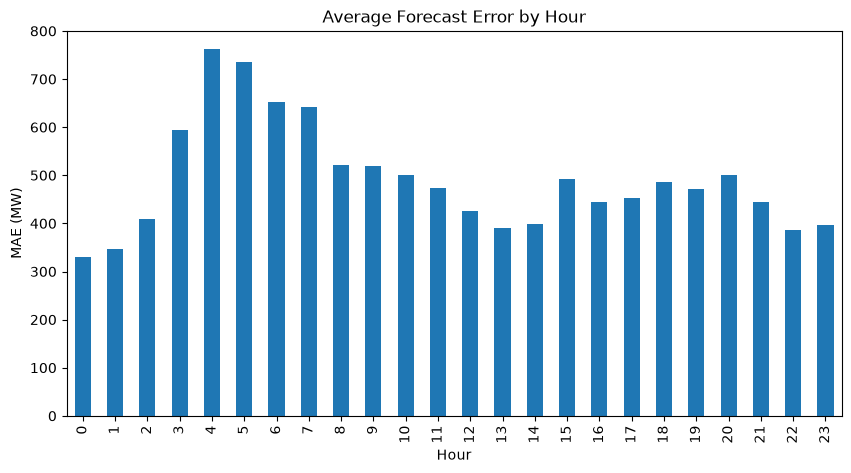

In [37]:
plt.figure(figsize=(10,5))

hour_error.plot(
    kind="bar"
)

plt.title(
    "Average Forecast Error by Hour"
)

plt.ylabel(
    "MAE (MW)"
)

plt.xlabel(
    "Hour"
)

plt.show()

In [38]:
error_analysis["month"] = (
    error_analysis["datetime"]
    .dt.month
)


month_error = (
    error_analysis
    .groupby("month")["abs_error"]
    .mean()
)


month_error

month
1    449.280273
2    452.156155
3    538.921544
4    608.519260
5    567.701298
6    538.857449
7    458.600187
8    409.494629
9    391.963726
Name: abs_error, dtype: float64

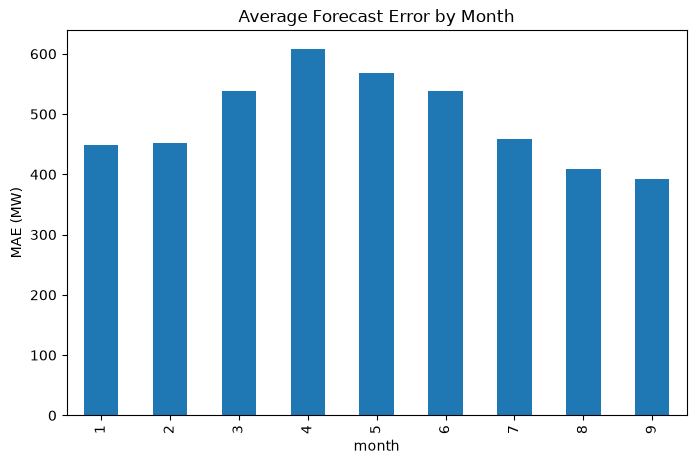

In [39]:
plt.figure(figsize=(8,5))

month_error.plot(
    kind="bar"
)

plt.title(
    "Average Forecast Error by Month"
)

plt.ylabel(
    "MAE (MW)"
)

plt.show()

In [40]:
error_analysis["direction"] = np.where(
    error_analysis["error"] > 0,
    "Under Prediction",
    "Over Prediction"
)


error_analysis["direction"].value_counts()

direction
Over Prediction     3298
Under Prediction    3278
Name: count, dtype: int64

In [41]:
worst_cases = (
    error_analysis
    .sort_values(
        by="abs_error",
        ascending=False
    )
    .head(10)
)


worst_cases

,datetime,actual,prediction,error,abs_error,hour,month,direction
46303,2020-04-20 07:00:00,57561.0,61214.703125,-3653.703125,3653.703125,7,4,Over Prediction
43661,2020-01-01 05:00:00,37510.0,41147.277344,-3637.277344,3637.277344,5,1,Over Prediction
47308,2020-06-01 04:00:00,33129.0,36578.238281,-3449.238281,3449.238281,4,6,Over Prediction
46013,2020-04-08 05:00:00,54197.0,57428.800781,-3231.800781,3231.800781,5,4,Over Prediction
45797,2020-03-30 05:00:00,56385.0,59514.945312,-3129.945312,3129.945312,5,3,Over Prediction
47284,2020-05-31 04:00:00,32507.0,35507.882812,-3000.882812,3000.882812,4,5,Over Prediction
46157,2020-04-14 05:00:00,51590.0,54543.773438,-2953.773438,2953.773438,5,4,Over Prediction
47668,2020-06-16 04:00:00,51445.0,48510.843750,2934.156250,2934.156250,4,6,Under Prediction
45777,2020-03-29 09:00:00,53984.0,51081.500000,2902.500000,2902.500000,9,3,Under Prediction
44957,2020-02-24 05:00:00,55944.0,58694.179688,-2750.179688,2750.179688,5,2,Over Prediction


In [43]:
import joblib

joblib.dump(
    xgb,
    "../models/xgboost_load_forecasting.pkl"
)

['../models/xgboost_load_forecasting.pkl']